In [1]:
# Implement Feed Forward neural network on Fashion-MNIST dataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
print(x_train.shape)   # (60000, 28, 28)

(60000, 28, 28)


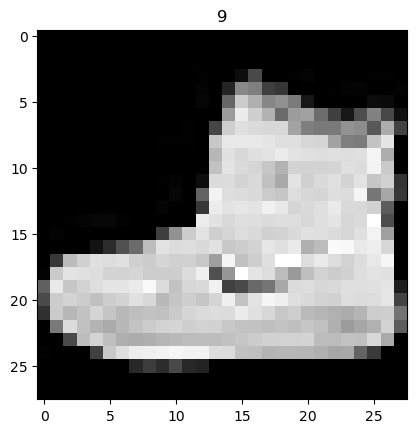

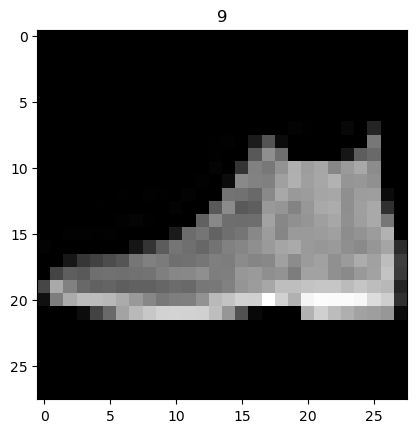

In [3]:
# 2. Visualize some training and test samples
plt.imshow(x_train[0], cmap="gray")
plt.title(y_train[0])
plt.show()
plt.imshow(x_test[0], cmap="gray")
plt.title(y_test[0])
plt.show()


In [4]:
# 3. Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0


In [5]:
# 4. Build the feed-forward neural network
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28,28)))       # Input layer
model.add(keras.layers.Dense(128, activation='relu'))      # Hidden layer
model.add(keras.layers.Dense(10, activation='softmax'))    # Output layer (10 classes of clothing)

C:\Users\sheeb\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# 5. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# 6. Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8244 - loss: 0.4982
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8670 - loss: 0.3731
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8780 - loss: 0.3328
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8859 - loss: 0.3102
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8927 - loss: 0.2927


In [8]:

# 7. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8730 - loss: 0.3540
Test Accuracy: 0.8730000257492065


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)


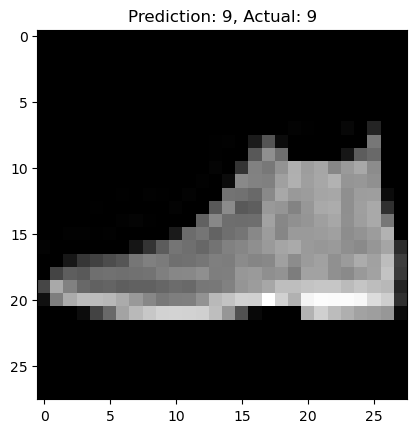

In [9]:
# 8. Predictions
predictions = model.predict(x_test)
print(predictions.shape)   # (10000, 10)

# Show prediction for one test image
i = 0
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Prediction: {np.argmax(predictions[i])}, Actual: {y_test[i]}")
plt.show()